# Downstream tasks

In [1]:
import os
import sys
from pathlib import Path

import scanpy as sc
import squidpy as sq
import warnings

warnings.filterwarnings("ignore")

/home/lehnerl/miniconda3/envs/interscale_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/lehnerl/miniconda3/envs/interscale_env/lib/python3.13/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/lehnerl/miniconda3/envs/interscale_env/lib/python3.13/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
import interscale
from interscale.config import load_config
from interscale.evaluation.linear_probing import (
    classify,
    feature_sets_from_spec,
    probe_continuous,
    summarize,
    summarize_by_target,
    targets_of_interest,
)
from interscale.evaluation.downstream_regression import (
    attention_pairs,
    regress_attention,
    residual_flow,
    score_against_truth,
)
from interscale.evaluation.synthetic_data import make_synthetic

interscale.tl.set_full_reproducibility()

In [ ]:
BASE_DIR_PROJECT = Path.cwd().resolve().parent.parent

sys.path.insert(0, str(BASE_DIR_PROJECT))
DATA = "synth_data_0"
RESULTS_DIR = Path(f"{BASE_DIR_PROJECT}/results/{DATA}")

## Load model

In [4]:
adata = sc.read_h5ad("/home/lehnerl/Arbeit/data/legnini_trained.h5ad")
#cfg = load_config(Path("/home/lehnerl/Arbeit/results/new.yaml"))

In [ ]:
interscale.model.CombinedModel._setup_anndata(
    adata=adata,
    prediction_task=cfg.dataset.prediction_task,
    layer_key=cfg.dataset.layer_key,
    sample_key_list=cfg.dataset.sample_key,
    prediction_obs=cfg.dataset.prediction_obs,
    view_registry=False,
)

model = interscale.model.CombinedModel.load(
    os.path.join(RESULTS_DIR),
    adata,
    cfg,
    local_component=True,
    global_component=True,
)


In [ ]:
adata = model.get_model_output(adata, prefix="combined")

## Classification

In [ ]:
res = classify(adata, "cell_type", level="node", sample_key="slide", group_key="donor", layer="log1p_norm")
summarize(res)

In [ ]:
res_cond = classify(adata, "condition", level="graph", sample_key="slide", group_key="donor", layer="log1p_norm")
summarize(res_cond)

In [ ]:
sets = feature_sets_from_spec(
    adata,
    [
        "combined_local_emb",
        "combined_global_emb",
        "combined_local_emb+combined_global_emb",
        "X_pca",
        "expression",
    ],
)

summarize(classify(adata, "niche", feature_sets=sets, level="node", layer="log1p_norm"))

## Gene probes

In [ ]:
targets = targets_of_interest(adata, n_noise_controls=4)
gene_res = probe_continuous(adata, targets, layer="log1p_norm")
summarize_by_target(gene_res, eval_split="test")

## Regression

In [ ]:
pairs = attention_pairs(
    adata,
    prefix="combined",
    sample_key="slide",
    obs_features=("cell_type", "niche", "total_counts", "n_genes_by_counts"),
    normalize="graph_z",
    max_pairs=200_000,
)

pairs.head()

In [ ]:
result = regress_attention(pairs, estimator="ridge", group_key="graph", cv_folds=5)
result.variance

In [ ]:
result.nonlinear_r2

In [ ]:
residual_flow(result.pairs)

In [ ]:
score_against_truth(adata, result.pairs)

## Create the synthetic dataset

In [3]:
adata_synth = make_synthetic()
adata_synth

INFO     Creating graph using `None` transform and `24` libraries.                                                 


AnnData object with n_obs × n_vars = 36000 × 42
    obs: 'condition', 'donor', 'slide', 'cell_type', 'niche', 'lr_tone', 'lr_neighbor_tone', 'n_contacts', 'dist_to_center', 'dist_to_hub', 'hub_response', 'n_senderA_short', 'kern_senderB_mid', 'lib_factor', 'split', 'total_counts', 'n_genes_by_counts'
    var: 'program', 'effect_size', 'target_cell_type', 'true_length_scale', 'is_spatial'
    uns: 'log1p', 'spatial_neighbors', 'synthetic'
    obsm: 'spatial'
    layers: 'counts', 'log1p_norm', 'norm_ftsqrt'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [4]:
adata_synth.var

,program,effect_size,target_cell_type,true_length_scale,is_spatial
noise_00,noise,0.0,,NaN,False
noise_01,noise,0.0,,NaN,False
noise_02,noise,0.0,,NaN,False
noise_03,noise,0.0,,NaN,False
noise_04,noise,0.0,,NaN,False
noise_05,noise,0.0,,NaN,False
noise_06,noise,0.0,,NaN,False
noise_07,noise,0.0,,NaN,False
noise_08,noise,0.0,,NaN,False
noise_09,noise,0.0,,NaN,False


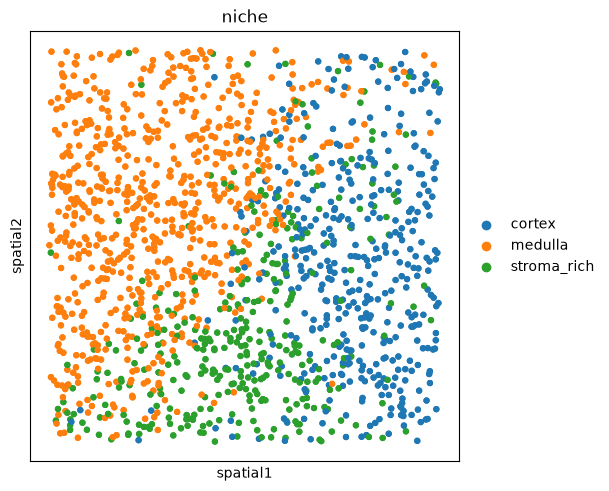

In [5]:
sq.pl.spatial_scatter(adata_synth, color="niche", shape=None, library_key="slide", library_id="D06_s2", size=50)

In [6]:
adata_synth.write_h5ad(f"/home/lehnerl/Arbeit/data/synth_data_0.h5ad")